# Spaceship Titanic - CatBoost Model (Python)
This notebook replicates the R pipeline using CatBoost.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

In [2]:
# Load Data
data = pd.read_csv("../data/preprocessed_data.csv")
test = pd.read_csv("../data/preprocessed_test.csv")

data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,DeckF,DeckG,DeckT,DeckG_midCabin,DeckE_midCabin,DeckF_midCabin,CryoSleep_spending_conflict,NoSpending_notCryo,total_spending_family,avg_spending_family
0,0001_01,Europa,0,B/0/P,TRAPPIST-1e,39.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0.0
1,0002_01,Earth,0,F/0/S,TRAPPIST-1e,24.0,0,109,9,25,...,1,0,0,0,0,0,0,0,736,736.0
2,0003_01,Europa,0,A/0/S,TRAPPIST-1e,58.0,1,43,3576,0,...,0,0,0,0,0,0,0,0,15559,7779.5
3,0003_02,Europa,0,A/0/S,TRAPPIST-1e,33.0,0,0,1283,371,...,0,0,0,0,0,0,0,0,15559,7779.5
4,0004_01,Earth,0,F/1/S,TRAPPIST-1e,16.0,0,303,70,151,...,1,0,0,0,0,0,0,0,1091,1091.0


In [3]:
data.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'Group', 'Number', 'total_spending', 'Deck',
       'Cabin_num', 'Side', 'GroupNumberCount', 'LastName',
       'FamilyMembersCount', 'FamilyMembersCabinCount', 'NameFlag',
       'CabinMidFlag', 'HomePlanetEarth', 'HomePlanetEuropa', 'HomePlanetMars',
       'HomePlanetOther', 'Destination55 Cancri e', 'DestinationOther',
       'DestinationPSO J318.5-22', 'DestinationTRAPPIST-1e', 'Group1',
       'Group2', 'Group3', 'Group4', 'Group5', 'Group6', 'Group7', 'Group8',
       'DeckA', 'DeckB', 'DeckC', 'DeckD', 'DeckE', 'DeckF', 'DeckG', 'DeckT',
       'DeckG_midCabin', 'DeckE_midCabin', 'DeckF_midCabin',
       'CryoSleep_spending_conflict', 'NoSpending_notCryo',
       'total_spending_family', 'avg_spending_family'],
      dtype='str')

In [4]:
# Selected Columns
selected_columns = [
    "CryoSleep", "Age", "VIP", "RoomService", "FoodCourt",
    "ShoppingMall", "Spa", "VRDeck", "Cabin_num", "Side",
    "CabinMidFlag", "HomePlanetEarth", "HomePlanetEuropa",
    "HomePlanetMars", "Destination55 Cancri e",
    "DestinationPSO J318.5-22", "DestinationTRAPPIST-1e",
    "Group1", "Group2", "Group3", "Group4", "Group5",
    "Group6", "Group7", "DeckA", "DeckB", "DeckC",
    "DeckD", "DeckE", "DeckF", "DeckG",
    "FamilyMembersCabinCount", "avg_spending_family"
]

target_column = "Transported" 

In [5]:
# Prepare Data
X = data[selected_columns]
y = data[target_column]

X_train, X_holdout, y_train, y_holdout = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

In [6]:
# Parameter grid
param_grid = {
    'iterations': [300, 500, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 64, 128]
}

# Base CatBoost model
cat = CatBoostClassifier(loss_function='Logloss', eval_metric='Accuracy', verbose=0)

In [ ]:
grid_search = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,   # 5-fold cross-validation
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation accuracy:", grid_search.best_score_)

In [ ]:
best_params = grid_search.best_params_

best_model = CatBoostClassifier(
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    border_count=best_params['border_count'],
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=100
)

best_model.fit(X_train, y_train)

In [ ]:
# Predictions
preds = best_model.predict(X_holdout)

In [ ]:
# Evaluation
print("Confusion Matrix:")
print(confusion_matrix(y_holdout, preds))

print("\nClassification Report:")
print(classification_report(y_holdout, preds))

Confusion Matrix:
[[356  76]
 [ 68 370]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       432
           1       0.83      0.84      0.84       438

    accuracy                           0.83       870
   macro avg       0.83      0.83      0.83       870
weighted avg       0.83      0.83      0.83       870



In [ ]:
# Feature Importance
importances = best_model.get_feature_importance()
feature_names = X_train.columns

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_imp

,Feature,Importance
6,Spa,10.892608
8,Cabin_num,10.351537
7,VRDeck,10.150703
0,CryoSleep,8.328126
3,RoomService,7.391468
1,Age,6.777043
4,FoodCourt,6.766832
32,avg_spending_family,5.734505
11,HomePlanetEarth,5.712842
9,Side,4.360698


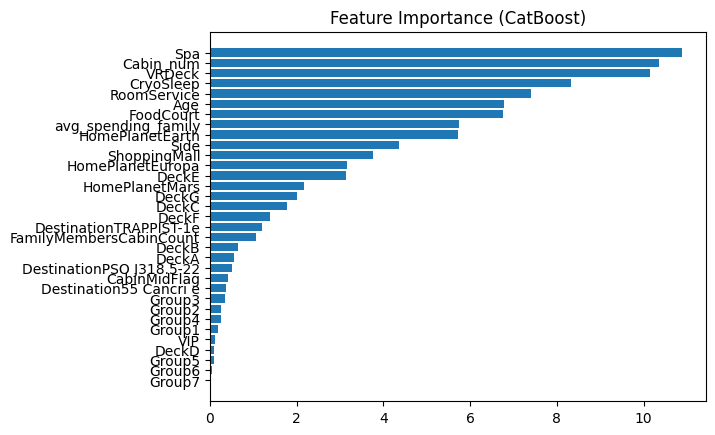

In [ ]:
# Plot Feature Importance
plt.figure()
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (CatBoost)")
plt.show()

In [ ]:
# Analyze Errors
holdout_df = X_holdout.copy()
holdout_df["Actual"] = y_holdout.values
holdout_df["Pred"] = preds

false_positive = holdout_df[
    (holdout_df["Pred"] == 1) & (holdout_df["Actual"] == 0)
]

false_negative = holdout_df[
    (holdout_df["Pred"] == 0) & (holdout_df["Actual"] == 1)
]

false_positive.describe(), false_negative.describe()

(       CryoSleep        Age        VIP  RoomService    FoodCourt  \
 count  76.000000  76.000000  76.000000    76.000000    76.000000   
 mean    0.552632  29.070766   0.013158    14.302632   302.921053   
 std     0.500526  15.641233   0.114708    58.286652  1214.616019   
 min     0.000000   0.000000   0.000000     0.000000     0.000000   
 25%     0.000000  19.000000   0.000000     0.000000     0.000000   
 50%     1.000000  26.000000   0.000000     0.000000     0.000000   
 75%     1.000000  40.250000   0.000000     0.000000     0.000000   
 max     1.000000  65.000000   1.000000   368.000000  9532.000000   
 
        ShoppingMall          Spa       VRDeck    Cabin_num       Side  ...  \
 count     76.000000    76.000000    76.000000    76.000000  76.000000  ...   
 mean     218.921053    62.000000    53.947368   600.947368   0.486842  ...   
 std      489.692768   306.714808   233.929157   522.958734   0.503148  ...   
 min        0.000000     0.000000     0.000000    14.000000  

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'CryoSleep'}>],
       [<Axes: title={'center': 'avg_spending_family'}>, <Axes: >]],
      dtype=object)

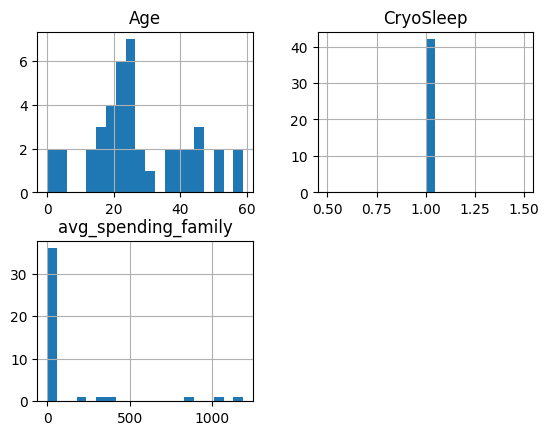

In [ ]:
false_positive_with_cryo = false_positive[false_positive["CryoSleep"] == 1]
false_positive_with_cryo[["Age", "CryoSleep", "avg_spending_family"]].hist(bins=20)

In [ ]:
false_positive_with_cryo.columns

Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Cabin_num', 'Side', 'CabinMidFlag', 'HomePlanetEarth',
       'HomePlanetEuropa', 'HomePlanetMars', 'Destination55 Cancri e',
       'DestinationPSO J318.5-22', 'DestinationTRAPPIST-1e', 'Group1',
       'Group2', 'Group3', 'Group4', 'Group5', 'Group6', 'Group7', 'DeckA',
       'DeckB', 'DeckC', 'DeckD', 'DeckE', 'DeckF', 'DeckG',
       'FamilyMembersCabinCount', 'avg_spending_family', 'Actual', 'Pred'],
      dtype='str')

In [ ]:
columns_to_check = ['Destination55 Cancri e','DestinationPSO J318.5-22', 'DestinationTRAPPIST-1e']

# Count 1s in each column
count_ones = false_positive_with_cryo[columns_to_check].apply(lambda x: (x == 1).sum())

In [ ]:
count_ones

Destination55 Cancri e       5
DestinationPSO J318.5-22    13
DestinationTRAPPIST-1e      23
dtype: int64

In [ ]:
false_positive_with_cryo.count()

CryoSleep                   42
Age                         42
VIP                         42
RoomService                 42
FoodCourt                   42
ShoppingMall                42
Spa                         42
VRDeck                      42
Cabin_num                   42
Side                        42
CabinMidFlag                42
HomePlanetEarth             42
HomePlanetEuropa            42
HomePlanetMars              42
Destination55 Cancri e      42
DestinationPSO J318.5-22    42
DestinationTRAPPIST-1e      42
Group1                      42
Group2                      42
Group3                      42
Group4                      42
Group5                      42
Group6                      42
Group7                      42
DeckA                       42
DeckB                       42
DeckC                       42
DeckD                       42
DeckE                       42
DeckF                       42
DeckG                       42
FamilyMembersCabinCount     42
avg_spen

In [ ]:
count = data[(data['CryoSleep'] == 1) & (data['DestinationTRAPPIST-1e'] == 1)].shape[0]
count

1926

<Axes: >

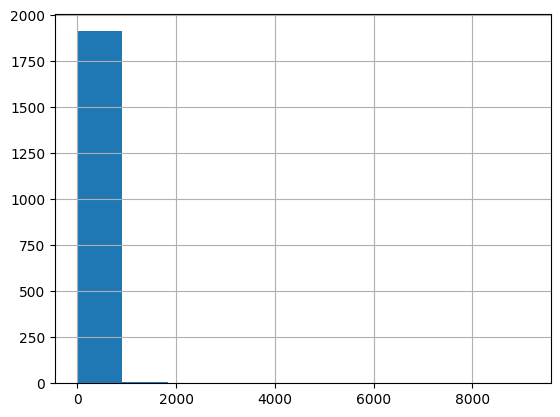

In [ ]:
unlogic = data[(data['CryoSleep'] == 1) & (data['DestinationTRAPPIST-1e'] == 1)]["total_spending"]
unlogic.hist()

In [ ]:
data['CryoSleep_spending_conflict'].sum()

np.int64(31)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# selected_columns = [
#     "CryoSleep", "Age", "VIP", "RoomService", "FoodCourt",
#     "ShoppingMall", "Spa", "VRDeck", "Cabin_num", "Side",
#     "CabinMidFlag", "HomePlanetEarth", "HomePlanetEuropa",
#     "HomePlanetMars", "Destination55 Cancri e",
#     "DestinationPSO J318.5-22", "DestinationTRAPPIST-1e",
#     "Group1", "Group2", "Group3", "Group4", "Group5",
#     "Group6", "Group7", "DeckA", "DeckB", "DeckC",
#     "DeckD", "DeckE", "DeckF", "DeckG",
#     "FamilyMembersCabinCount"# , "total_spending"
# ]

data_selected = data[selected_columns]

# Select numeric features
numeric_features = data_selected.select_dtypes(include=['float64', 'int64'])

# Compute VIF
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_features.columns
vif_data["VIF"] = [variance_inflation_factor(numeric_features.values, i) 
                   for i in range(numeric_features.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

                     feature         VIF
17                    Group1  207.695708
29                     DeckF   93.405898
30                     DeckG   88.757430
18                    Group2   47.825508
16    DestinationTRAPPIST-1e   32.190575
28                     DeckE   29.106554
25                     DeckB   25.141548
26                     DeckC   24.333562
11           HomePlanetEarth   24.209340
19                    Group3   20.001083
27                     DeckD   15.799942
12          HomePlanetEuropa   15.614228
14    Destination55 Cancri e   10.627356
13            HomePlanetMars    9.976232
24                     DeckA    9.008438
20                    Group4    8.562440
1                        Age    5.723783
21                    Group5    5.306496
15  DestinationPSO J318.5-22    5.291138
32       avg_spending_family    5.143945
31   FamilyMembersCabinCount    4.882823
8                  Cabin_num    3.870153
22                    Group6    3.553088
0               

# Submission

In [ ]:
test_selected = test[selected_columns]


In [ ]:
test_preds = best_model.predict(test_selected)
test_preds = ["True" if pred == 1 else "False" for pred in test_preds]

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": test_preds
})

['True', 'False', 'True', 'True', 'True', 'True', 'True', 'True', 'True', 'True', 'False', 'False', 'False', 'False', 'False', 'False', 'False', 'True', 'True', 'False', 'False', 'False', 'True', 'True', 'False', 'False', 'True', 'True', 'True', 'True', 'True', 'False', 'True', 'False', 'False', 'False', 'True', 'True', 'False', 'False', 'True', 'False', 'True', 'True', 'False', 'True', 'False', 'False', 'False', 'False', 'True', 'True', 'False', 'True', 'False', 'True', 'False', 'True', 'True', 'False', 'True', 'True', 'False', 'True', 'True', 'False', 'True', 'False', 'True', 'False', 'False', 'True', 'False', 'False', 'True', 'False', 'True', 'True', 'False', 'True', 'True', 'False', 'False', 'False', 'True', 'True', 'True', 'False', 'True', 'True', 'False', 'False', 'False', 'False', 'False', 'False', 'True', 'False', 'True', 'True', 'True', 'True', 'True', 'False', 'True', 'False', 'True', 'True', 'False', 'True', 'True', 'False', 'True', 'True', 'False', 'True', 'True', 'False', 

In [ ]:
submission.to_csv("../output/catboost/submission.csv", index=False)